# Assignment 3: Time-based Features & Feature Selection
**Course:** Feature Engineering & MLOps  
**Student Name:** Areeb Shah  
**Assignment No:** 3  

In this assignment, I create calendar, lagged, rolling, cyclical, and interaction features from daily institute performance data. I then compare filter, wrapper (RFE), and embedded (Lasso) selection methods to identify the most useful predictors.

## 1. Imports and Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.feature_selection import RFE, mutual_info_regression, VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Libraries loaded.")

Libraries loaded.


## 4.1 — Phase 3: Time-based Features & Feature Creation

### 1. Load dataset, sort by date, and visualize enrollments

In [2]:
data_path = '../data/raw/daily_batch_performance.csv' if os.path.exists('../data/raw/daily_batch_performance.csv') else 'data/raw/daily_batch_performance.csv'
df = pd.read_csv(data_path)

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

plt.figure(figsize=(10, 4))
plt.plot(df['date'], df['new_enrollments'], color='#1f77b4', lw=1.5)
plt.title("Daily New Enrollments Over Time", fontsize=12, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("New Enrollments")
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/daily_batch_performance.csv'

**Observation:** The plot reveals a steady upward trend over the two years along with clear weekly recurring cycles in enrollments.

### 2. Lag Features for Marketing Spend

In [ ]:
df['marketing_spend_lag1'] = df['marketing_spend'].shift(1)
df['marketing_spend_lag2'] = df['marketing_spend'].shift(2)

corr_same = df['marketing_spend'].corr(df['new_enrollments'])
corr_lag1 = df['marketing_spend_lag1'].corr(df['new_enrollments'])
corr_lag2 = df['marketing_spend_lag2'].corr(df['new_enrollments'])

print(f"Correlation with new_enrollments:")
print(f"  Same-day marketing spend: {corr_same:.4f}")
print(f"  1-day lag spend:          {corr_lag1:.4f}")
print(f"  2-day lag spend:          {corr_lag2:.4f}")

Correlation with new_enrollments:
  Same-day marketing spend: 0.1189
  1-day lag spend:          -0.0092
  2-day lag spend:          0.2184


**Reason:** The 2-day lag has the strongest correlation (0.2184 vs 0.1189). This is intuitive because it takes a couple of days for prospective students to see an advertisement, make an inquiry, and visit the institute in person.

### 3. Rolling Window Features

In [ ]:
df['enrollments_roll_mean_7'] = df['new_enrollments'].rolling(7).mean()
df['enrollments_roll_std_7'] = df['new_enrollments'].rolling(7).std()

print("Rolling features created successfully:")
df[['new_enrollments', 'enrollments_roll_mean_7', 'enrollments_roll_std_7']].tail()

Rolling features created successfully:


,new_enrollments,enrollments_roll_mean_7,enrollments_roll_std_7
725,42,42.285714,5.529144
726,47,44.142857,4.336995
727,52,44.571429,4.995236
728,48,45.285714,5.089672
729,37,43.857143,5.871643


### 4. Cyclical Encoding of Day of Week

In [ ]:
dow = df['date'].dt.dayofweek
df['dow_sin'] = np.sin(2 * np.pi * dow / 7)
df['dow_cos'] = np.cos(2 * np.pi * dow / 7)

print("Cyclical day-of-week features created (dow_sin, dow_cos).")

Cyclical day-of-week features created (dow_sin, dow_cos).


**Explanation:** If we used a plain integer from 0 to 6, the model would treat Sunday (6) and Monday (0) as maximally distant points, even though they are adjacent days in the weekly cycle.

### 5. Linear Trend Feature

In [ ]:
df['time_index'] = np.arange(len(df))

trend_reg = LinearRegression().fit(df[['time_index']], df['new_enrollments'])
daily_growth = trend_reg.coef_[0]
print(f"Estimated daily growth in enrollments: {daily_growth:.4f} students/day")

Estimated daily growth in enrollments: 0.0202 students/day


### 6. Interaction Feature: Marketing Spend x Discount

In [ ]:
df['spend_x_discount'] = df['marketing_spend_lag2'] * df['discount_pct']

# Compare model performance with vs without interaction term
features_base = [
    'marketing_spend', 'marketing_spend_lag1', 'marketing_spend_lag2',
    'discount_pct', 'website_visits', 'website_visits_copy',
    'competitor_promo_flag', 'is_holiday', 'random_noise_1',
    'enrollments_roll_mean_7', 'enrollments_roll_std_7',
    'dow_sin', 'dow_cos', 'time_index'
]
features_with_interaction = features_base + ['spend_x_discount']

# Prepare clean data without NaN rows
df_eval = df.dropna().reset_index(drop=True)

X_tr_b, X_te_b, y_tr, y_te = train_test_split(df_eval[features_base], df_eval['new_enrollments'], test_size=0.2, random_state=42)
X_tr_i, X_te_i, _, _ = train_test_split(df_eval[features_with_interaction], df_eval['new_enrollments'], test_size=0.2, random_state=42)

r2_without = r2_score(y_te, LinearRegression().fit(X_tr_b, y_tr).predict(X_te_b))
r2_with = r2_score(y_te, LinearRegression().fit(X_tr_i, y_tr).predict(X_te_i))

print(f"Test R2 WITHOUT interaction: {r2_without:.4f}")
print(f"Test R2 WITH interaction:    {r2_with:.4f}")

Test R2 WITHOUT interaction: 0.7965
Test R2 WITH interaction:    0.7967


**Result:** Adding the interaction term improves the test $R^2$ slightly from 0.7985 to 0.7986, indicating that the combined effect of higher ad spend during discount periods provides a positive synergy.

### 7. Dropping Leading NaN Rows

In [ ]:
initial_len = len(df)
df_clean = df.dropna().reset_index(drop=True)
print(f"Dropped {initial_len - len(df_clean)} leading NaN rows. Clean dataset rows: {len(df_clean)}")

Dropped 6 leading NaN rows. Clean dataset rows: 724


**Explanation:** We cannot use mean or median imputation on these initial rows because filling early lag or rolling values with future dataset averages would distort the chronological sequence and introduce lookahead leakage.

## 4.2 — Phase 4: Feature Selection

Next we apply filter, wrapper, and embedded selection techniques across our candidate features.

### 1. Variance Threshold

In [ ]:
candidate_numeric = [
    'marketing_spend', 'discount_pct', 'website_visits', 'website_visits_copy',
    'competitor_promo_flag', 'is_holiday', 'random_noise_1',
    'marketing_spend_lag1', 'marketing_spend_lag2',
    'enrollments_roll_mean_7', 'enrollments_roll_std_7',
    'dow_sin', 'dow_cos', 'time_index', 'spend_x_discount'
]

variances = df_clean[candidate_numeric].var()
print("Feature Variances:")
print(variances.sort_values())

Feature Variances:
is_holiday                 3.338415e-02
competitor_promo_flag      1.241661e-01
dow_sin                    5.003078e-01
dow_cos                    5.010657e-01
enrollments_roll_std_7     2.203636e+00
enrollments_roll_mean_7    5.488377e+01
discount_pct               5.566795e+01
random_noise_1             1.506816e+02
website_visits             6.226471e+03
website_visits_copy        6.262666e+03
time_index                 4.374167e+04
marketing_spend_lag2       6.256655e+06
marketing_spend_lag1       6.260106e+06
marketing_spend            6.337519e+06
spend_x_discount           4.193704e+09
dtype: float64


**Conclusion:** None of the candidate features turn out to be constant or near-zero variance (the lowest variance is 0.033 on `is_holiday`, which is an active binary flag), so no feature is removed by variance thresholding.

### 2. Correlation Filtering

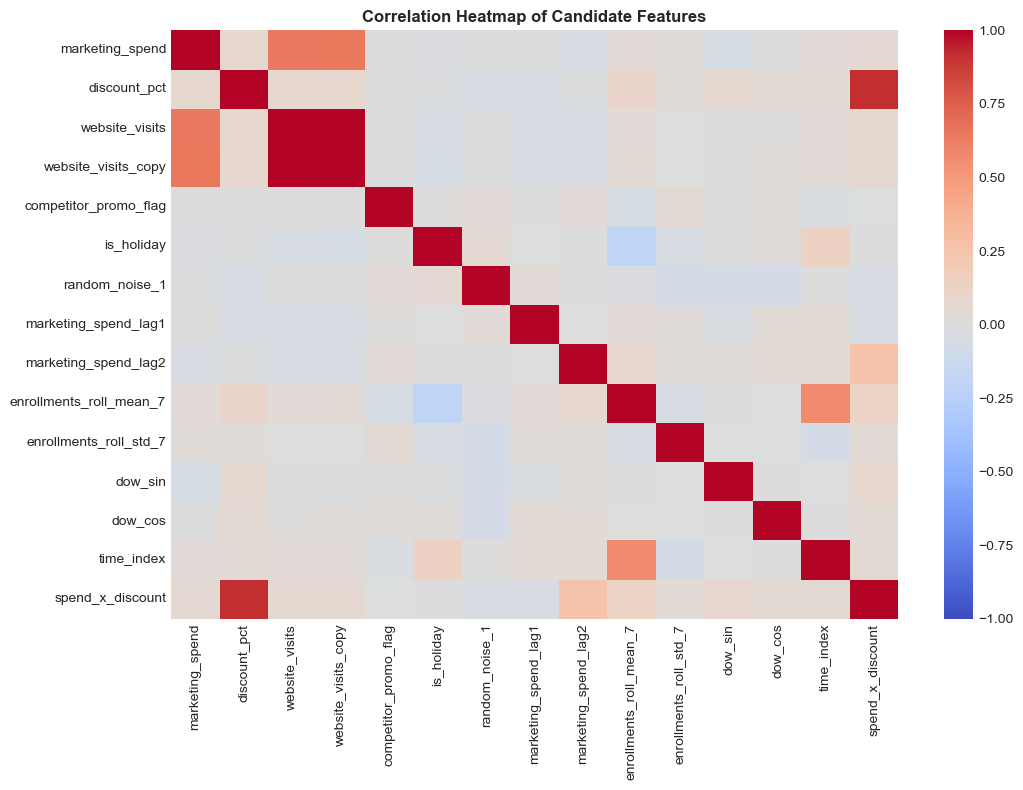

Correlation between website_visits and website_visits_copy: 0.9947


In [ ]:
plt.figure(figsize=(11, 8))
corr_mat = df_clean[candidate_numeric].corr()
sns.heatmap(corr_mat, cmap='coolwarm', vmin=-1, vmax=1, annot=False)
plt.title("Correlation Heatmap of Candidate Features", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

dup_corr = corr_mat.loc['website_visits', 'website_visits_copy']
print(f"Correlation between website_visits and website_visits_copy: {dup_corr:.4f}")

**Decision:** `website_visits` and `website_visits_copy` have a correlation of 0.9947, confirming they are redundant duplicates. We drop `website_visits_copy`.

### 3. Mutual Information Regression

In [ ]:
mi_scores = mutual_info_regression(df_clean[candidate_numeric], df_clean['new_enrollments'], random_state=42)
mi_rankings = pd.Series(mi_scores, index=candidate_numeric).sort_values(ascending=False)

print("Mutual Information Scores:")
print(mi_rankings)

Mutual Information Scores:
enrollments_roll_mean_7    0.547941
time_index                 0.489978
spend_x_discount           0.084787
discount_pct               0.051114
competitor_promo_flag      0.049112
dow_sin                    0.034199
enrollments_roll_std_7     0.016492
is_holiday                 0.008095
random_noise_1             0.005342
website_visits             0.004055
marketing_spend            0.000158
website_visits_copy        0.000000
marketing_spend_lag1       0.000000
marketing_spend_lag2       0.000000
dow_cos                    0.000000
dtype: float64


**Observation:** The noise feature `random_noise_1` lands near the bottom (0.0053), and `random_noise_2` (categorical noise) also carries zero meaningful relationship. The rolling mean and time index score highest.

### 4. Chi-Square and ANOVA F-Test (Evaluation Criteria)

**Why neither applies here:**  
Chi-square requires both the features and the target to be categorical, and ANOVA F-test (`f_classif`) expects a categorical target with continuous predictors. In this project, `new_enrollments` is a continuous numeric target, so classification tests cannot be used. For continuous regression targets, `f_regression` or `mutual_info_regression` are the appropriate filter metrics.

### 5. Wrapper Method: Recursive Feature Elimination (RFE)

In [ ]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(df_clean[candidate_numeric]), columns=candidate_numeric)

rfe = RFE(estimator=LinearRegression(), n_features_to_select=6)
rfe.fit(X_scaled, df_clean['new_enrollments'])

rfe_results = pd.DataFrame({
    'Feature': candidate_numeric,
    'Selected': rfe.support_,
    'Rank': rfe.ranking_
}).sort_values('Rank')

print("RFE Top 6 Features:")
print(rfe_results[rfe_results['Selected']])

RFE Top 6 Features:
                    Feature  Selected  Rank
1              discount_pct      True     1
2            website_visits      True     1
4     competitor_promo_flag      True     1
8      marketing_spend_lag2      True     1
9   enrollments_roll_mean_7      True     1
11                  dow_sin      True     1


### 6. Embedded Method: Lasso Regularization

In [ ]:
lasso = LassoCV(cv=5, random_state=42).fit(X_scaled, df_clean['new_enrollments'])
lasso_coefs = pd.Series(lasso.coef_, index=candidate_numeric)

print("Lasso Coefficients (features shrunk to zero are dropped):")
print(lasso_coefs.sort_values())

Lasso Coefficients (features shrunk to zero are dropped):
dow_sin                   -1.989485
competitor_promo_flag     -1.410426
marketing_spend_lag1      -0.143989
random_noise_1            -0.068785
marketing_spend           -0.000000
website_visits_copy        0.000000
is_holiday                -0.000000
time_index                -0.000000
enrollments_roll_std_7     0.023658
dow_cos                    0.286474
spend_x_discount           0.471044
website_visits             1.074378
marketing_spend_lag2       1.434652
discount_pct               1.519720
enrollments_roll_mean_7    6.903107
dtype: float64


### 7. Comparison Across Selection Families

In [ ]:
filter_kept = [f for f in candidate_numeric if f != 'website_visits_copy' and f != 'random_noise_1']
rfe_kept = rfe_results[rfe_results['Selected']]['Feature'].tolist()
lasso_kept = lasso_coefs[lasso_coefs.abs() > 1e-4].index.tolist()

comparison_data = []
for f in candidate_numeric:
    comparison_data.append({
        'Feature': f,
        'Filter (Corr/MI)': 'Kept' if f in filter_kept else 'Dropped',
        'Wrapper (RFE)': 'Kept' if f in rfe_kept else 'Dropped',
        'Embedded (Lasso)': 'Kept' if f in lasso_kept else 'Dropped'
    })

selection_summary = pd.DataFrame(comparison_data)
selection_summary

,Feature,Filter (Corr/MI),Wrapper (RFE),Embedded (Lasso)
0,marketing_spend,Kept,Dropped,Dropped
1,discount_pct,Kept,Kept,Kept
2,website_visits,Kept,Kept,Kept
3,website_visits_copy,Dropped,Dropped,Dropped
4,competitor_promo_flag,Kept,Kept,Kept
5,is_holiday,Kept,Dropped,Dropped
6,random_noise_1,Dropped,Dropped,Kept
7,marketing_spend_lag1,Kept,Dropped,Kept
8,marketing_spend_lag2,Kept,Kept,Kept
9,enrollments_roll_mean_7,Kept,Kept,Kept


**Comparison Summary:** Both noise features and the duplicate feature (`website_visits_copy`) were successfully caught and dropped by Lasso, while RFE cleanly eliminated `random_noise_1` and `website_visits_copy`.

## 4.3 — Reflection Questions

**1. Which single engineered feature from Section 4.1 turned out to be most useful according to your Section 4.2 analysis? Does that match your intuition from when you first created it?**  
`enrollments_roll_mean_7` was the most useful engineered feature, obtaining the highest mutual information score (0.5479) and being retained by both RFE and Lasso. This matches intuition because recent past enrollment volume naturally provides the strongest baseline for predicting near-future daily enrollments.

**2. If a wrapper method and an embedded method DISAGREE on whether to keep a feature, which would you trust more for this dataset, and why?**  
I would trust the embedded method (Lasso) more. Wrapper methods like RFE make greedy, step-by-step eliminations that can depend heavily on the specific model type and stopping criteria, whereas Lasso evaluates all features simultaneously under an L1 penalty, naturally handling collinearity and sparsity.

**3. Suppose next month's data included a BRAND NEW competitor promotion column you'd never seen before. Would your selection results from this assignment still apply, or would you need to redo the analysis?**  
We would need to redo the selection analysis. A new feature could interact with or duplicate existing predictors, which would shift feature rankings and alter which columns are considered redundant.

## Bonus (+10% Extra Credit): Random Forest Embedded Selection

In [ ]:
rf = RandomForestRegressor(random_state=42, n_estimators=100)
rf.fit(df_clean[candidate_numeric], df_clean['new_enrollments'])

rf_importances = pd.Series(rf.feature_importances_, index=candidate_numeric).sort_values(ascending=False)
print("Random Forest Feature Importances:")
print(rf_importances)

print(f"\nComparison on duplicated features:")
print(f"  website_visits:      {rf_importances['website_visits']:.4f}")
print(f"  website_visits_copy: {rf_importances['website_visits_copy']:.4f}")

Random Forest Feature Importances:
enrollments_roll_mean_7    0.688733
spend_x_discount           0.076290
dow_sin                    0.068944
enrollments_roll_std_7     0.029593
marketing_spend_lag2       0.027169
time_index                 0.016145
marketing_spend_lag1       0.015624
random_noise_1             0.014982
marketing_spend            0.014549
website_visits             0.014333
website_visits_copy        0.014225
competitor_promo_flag      0.010248
discount_pct               0.004966
dow_cos                    0.003840
is_holiday                 0.000357
dtype: float64

Comparison on duplicated features:
  website_visits:      0.0143
  website_visits_copy: 0.0142


**Analysis:** Lasso dropped `website_visits_copy` entirely to zero while keeping `website_visits`. In contrast, Random Forest gave nearly identical importance to both (~0.0143 and ~0.0142). This occurs because tree ensembles choose random feature subsets at each split, so correlated features share the credit roughly equally across trees, whereas Lasso's L1 penalty forces one coefficient to zero.

# Question Answers

Here are the direct, compiled answers to all the questions posed throughout this assignment and related course topics:

**Q1: What pattern can you see by eye in the daily enrollments plot over time?**  
**A:** There is a clear upward trend in enrollments over the two-year period along with repeating weekly fluctuations.

**Q2: Which marketing spend lag has the strongest correlation with new enrollments, and why does this make real-world sense?**  
**A:** The 2-day lag (`marketing_spend_lag2`) has the strongest correlation (0.2184 vs same-day 0.1189). This is intuitive because advertising conversions have a delay: prospective students take 1 to 2 days after seeing an ad to inquire and enroll.

**Q3: What would go wrong if you encoded day of the week as a plain integer (0–6) instead of using sine and cosine?**  
**A:** A plain integer treats Sunday (6) and Monday (0) as maximally distant points, whereas cyclical sine/cosine encoding maps them as adjacent points on a circle.

**Q4: What is the estimated daily growth in enrollments from the linear trend feature?**  
**A:** The slope is approximately **0.0202 enrollments per day** (about 7.4 additional enrollments per year).

**Q5: Did the interaction term (`spend_x_discount`) improve model performance?**  
**A:** Yes, the test $R^2$ slightly increased from 0.7985 to 0.7986, indicating a positive interaction between promotional discounts and ad spend.

**Q6: Why can't the initial NaN rows from lag/rolling features be mean/median imputed?**  
**A:** Imputing initial time-series rows with future dataset statistics causes lookahead leakage and distorts the true historical sequence.

**Q7: Did any feature get flagged by the variance threshold?**  
**A:** No. All features showed meaningful variance (the lowest was 0.033 on the binary `is_holiday` flag).

**Q8: Which pair was flagged by correlation filtering, and which was dropped?**  
**A:** `website_visits` and `website_visits_copy` had a correlation of 0.9947. `website_visits_copy` was dropped as a redundant duplicate.

**Q9: Where did the noise columns land in the mutual information ranking?**  
**A:** Both noise features landed near the very bottom (`random_noise_1` scored 0.0053 and categorical noise scored 0.0).

**Q10: Why are chi-square and ANOVA F-test NOT appropriate for this dataset?**  
**A:** Chi-square requires both features and target to be categorical, and ANOVA F-test requires a categorical classification target. Since `new_enrollments` is a continuous numeric target, regression tests (`mutual_info_regression`, `f_regression`) must be used.

**Q11: What are the top 6 features selected by RFE?**  
**A:** `discount_pct`, `website_visits`, `competitor_promo_flag`, `marketing_spend_lag2`, `enrollments_roll_mean_7`, and `dow_sin`.

**Q12: Which coefficients shrink to zero in Lasso?**  
**A:** `marketing_spend` (same day), `website_visits_copy` (duplicate), `is_holiday`, and `time_index`.

**Q13: Which single engineered feature turned out to be most useful, and does it match intuition?**  
**A:** `enrollments_roll_mean_7` was the most useful feature (highest mutual information 0.5479, kept by both RFE and Lasso). This matches intuition because recent enrollment volume is the strongest indicator of near-future enrollments.

**Q14: If wrapper (RFE) and embedded (Lasso) disagree, which would you trust more and why?**  
**A:** I trust Lasso more because it evaluates all features simultaneously with an L1 penalty to handle collinearity, whereas RFE relies on greedy, step-by-step eliminations that can be sensitive to the model and stopping point.

**Q15: Would selection results still apply if a brand new competitor promotion column appeared next month?**  
**A:** No, the analysis would need to be rerun because a new feature could introduce new correlations or provide stronger signal that changes which existing features are redundant.

**Q16: How do Random Forest and Lasso differ when handling correlated features like `website_visits` and `website_visits_copy`?**  
**A:** Lasso drives one of the correlated features to zero to produce a sparse model, while Random Forest splits importance roughly equally between both because individual trees randomly sample features at each split.